# Week 8 - Evaluation Expansion
- Computing metrics beyond R^2 : MdAPE and MAPE, summarizing insights.

- **MdAPE** is the Median Absolute Percentage Error, is it best used as a measure of accuracy in predictive models. It is a calculation of how far off aprediction is from the actual outcome, as a percentage.

$$MdAPE = \text{median}\left( \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100 \right)$$
The middle value of all percentage errors. Robust to outliers and represents the 
"typical" prediction error. 
A MdAPE of 7.66% means the model's prediction is within 7.66% of the actual 
sale price for a typical California single-family home.

- **MAPE** is the Mean Absolute Percentage Error, it is a measure of prediction accuracy.

 $$MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100$$

The average percentage error across all predictions. Intuitive but sensitive to outliers a single wrong price can pull the mean up significantly.


In [30]:
# imports and best model predictions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import re

filepath = r"C:\Users\julia\downloads\IDX_summer_internship"


In [28]:
# updating test/train split to get validation set from last week, getting XGB metrics
def make_train_test_split(df, date_col='CloseDate', x_months=12):
    """
    Creates a time-based train/test split.
    
    Parameters:
        df: cleaned dataframe
        date_col: name of the date column to split on
        x_months: number of months to use for training window (tunable)
    
    Returns:
        train_df, test_df
    """
    df[date_col] = pd.to_datetime(df[date_col], format='mixed')
    
    latest_month = df[date_col].dt.to_period('M').max()
    cutoff_month = latest_month - x_months
    
    test_df = df[df[date_col].dt.to_period('M') == latest_month].copy()
    train_df = df[
        (df[date_col].dt.to_period('M') > cutoff_month) &
        (df[date_col].dt.to_period('M') < latest_month)
    ].copy()
    
    print(f"Test month: {latest_month}")
    print(f"Training window: {x_months} months ({cutoff_month} to {latest_month})")
    print(f"Training rows: {len(train_df):,}")
    print(f"Testing rows:  {len(test_df):,}")
    
    return train_df, test_df

train_full = pd.read_csv(filepath + r"\train_enriched.csv", low_memory=False)
train_df, test_df = make_train_test_split(train_full, x_months=30)

val_month = train_df["CloseDate"].dt.to_period("M").max()
val_df = train_df[train_df["CloseDate"].dt.to_period("M") == val_month].copy()
train_df = train_df[train_df["CloseDate"].dt.to_period("M") < val_month].copy()

print(f"Train: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

Test month: 2026-05
Training window: 30 months (2023-11 to 2026-05)
Training rows: 303,839
Testing rows:  11,844
Train: 292,001 rows
Val:   11,838 rows
Test:  11,844 rows


In [36]:
# rerunning XGB for metrics in this notebook

#making sure data columns are clean
def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

#_v added for validation set data
x_train_v = clean_col_names(x_train_v)
x_val_v   = clean_col_names(x_val_v)
x_test_v  = clean_col_names(x_test_v)

# retraining final XGBoost (best method as seen last week)
xgb_final = xgb.XGBRegressor(
    n_estimators=3000,
    max_depth=11,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    x_train_v, y_train_v,
    eval_set=[(x_val_v, y_val_v)],
    verbose=False
)

y_pred_xgb_final = xgb_final.predict(x_test_v)
print(f"Done — best trees: {xgb_final.best_iteration}")

Done — best trees: 916


In [14]:
# metrics function
def evaluate_model(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{label}")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"MdAPE: {mdape:.2f}%")
    
    return {"Model": label, "R2": r2, "RMSE": rmse,
            "MAE": mae, "MAPE": mape, "MdAPE": mdape}

In [41]:
# evaluation dataframe with custom price bands
eval_df = pd.DataFrame({
    "ActualPrice": y_test_v.values,
    "PredictedPrice": y_pred_xgb_final
})

eval_df["APE"] = np.abs(
    (eval_df["ActualPrice"] - eval_df["PredictedPrice"]) / eval_df["ActualPrice"]
) * 100

eval_df["AbsError"] = np.abs(eval_df["ActualPrice"] - eval_df["PredictedPrice"])

# custom price bands reflecting CA market distribution
bins = [0, 500000, 750000, 1000000, 2000000, float("inf")]
labels = ["Entry\n<$500k", "Mid\n$500k-$750k", "Upper Mid\n$750k-$1M", 
          "Luxury\n$1M-$2M", "Ultra Luxury\n>$2M"]

eval_df["PriceBand"] = pd.cut(eval_df["ActualPrice"], bins=bins, labels=labels)

# metrics per band
band_metrics = eval_df.groupby("PriceBand", observed=True).agg(
    Count=("ActualPrice", "count"),
    MedianPrice=("ActualPrice", "median"),
    MdAPE=("APE", "median"),
    MAPE=("APE", "mean"),
    MAE=("AbsError", "mean")
).round(2)

band_metrics["MAE"] = band_metrics["MAE"].map("${:,.0f}".format)
band_metrics["MedianPrice"] = band_metrics["MedianPrice"].map("${:,.0f}".format)

print(band_metrics)

                      Count MedianPrice  MdAPE   MAPE       MAE
PriceBand                                                      
Entry\n<$500k          1626    $409,950   8.00  14.14   $52,635
Mid\n$500k-$750k       2526    $634,400   6.29   9.69   $61,136
Upper Mid\n$750k-$1M   2372    $865,000   6.58   9.28   $81,267
Luxury\n$1M-$2M        3744  $1,365,000   8.62  11.28  $160,389
Ultra Luxury\n>$2M     1576  $2,791,500  11.25  14.15  $457,827


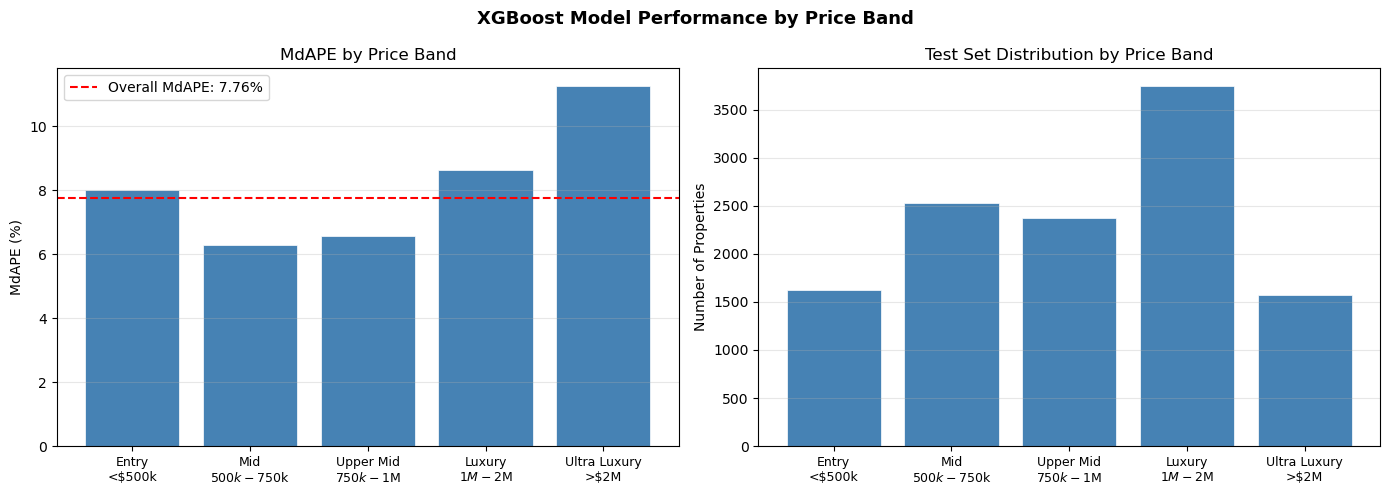

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bands = eval_df.groupby("PriceBand", observed=True)["APE"].median()
counts = eval_df.groupby("PriceBand", observed=True)["ActualPrice"].count()

# MdAPE by price band
axes[0].bar(range(len(bands)), bands.values, 
            color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].axhline(y=eval_df["APE"].median(), color="red", linestyle="--",
                label=f"Overall MdAPE: {eval_df['APE'].median():.2f}%")
axes[0].set_xticks(range(len(bands)))
axes[0].set_xticklabels(bands.index, fontsize=9)
axes[0].set_ylabel("MdAPE (%)")
axes[0].set_title("MdAPE by Price Band")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# count by price band
axes[1].bar(range(len(counts)), counts.values,
            color="steelblue", edgecolor="white", linewidth=0.5)
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(counts.index, fontsize=9)
axes[1].set_ylabel("Number of Properties")
axes[1].set_title("Test Set Distribution by Price Band")
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("XGBoost Model Performance by Price Band", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(filepath + r"\mdape_by_price_band.png", dpi=150, bbox_inches='tight')
plt.show()

Districts with 50+ test samples: 52

Best performing districts:
                         Count  MdAPE  MAPE  MedianPrice
District                                                
Antioch Unified             53   3.61  4.99     600000.0
Fontana Unified             59   4.04  6.24     649000.0
Beaumont Unified            71   4.31  5.28     552750.0
Temecula Valley Unified    150   4.53  6.04     760000.0
Corona-Norco Unified       146   4.71  6.53     880000.0
Moreno Valley Unified       88   4.77  6.46     546500.0
Murrieta Valley Unified     84   4.86  8.37     720000.0
Hesperia Unified            91   5.05  7.19     470000.0
Simi Valley Unified         87   5.10  6.25     900000.0
Chino Valley Unified        78   5.14  7.71     900100.0

Worst performing districts:
                           Count  MdAPE   MAPE  MedianPrice
District                                                   
Mt. Diablo Unified           146   9.88  11.70    1005000.0
West Contra Costa Unified     82  10.15  13

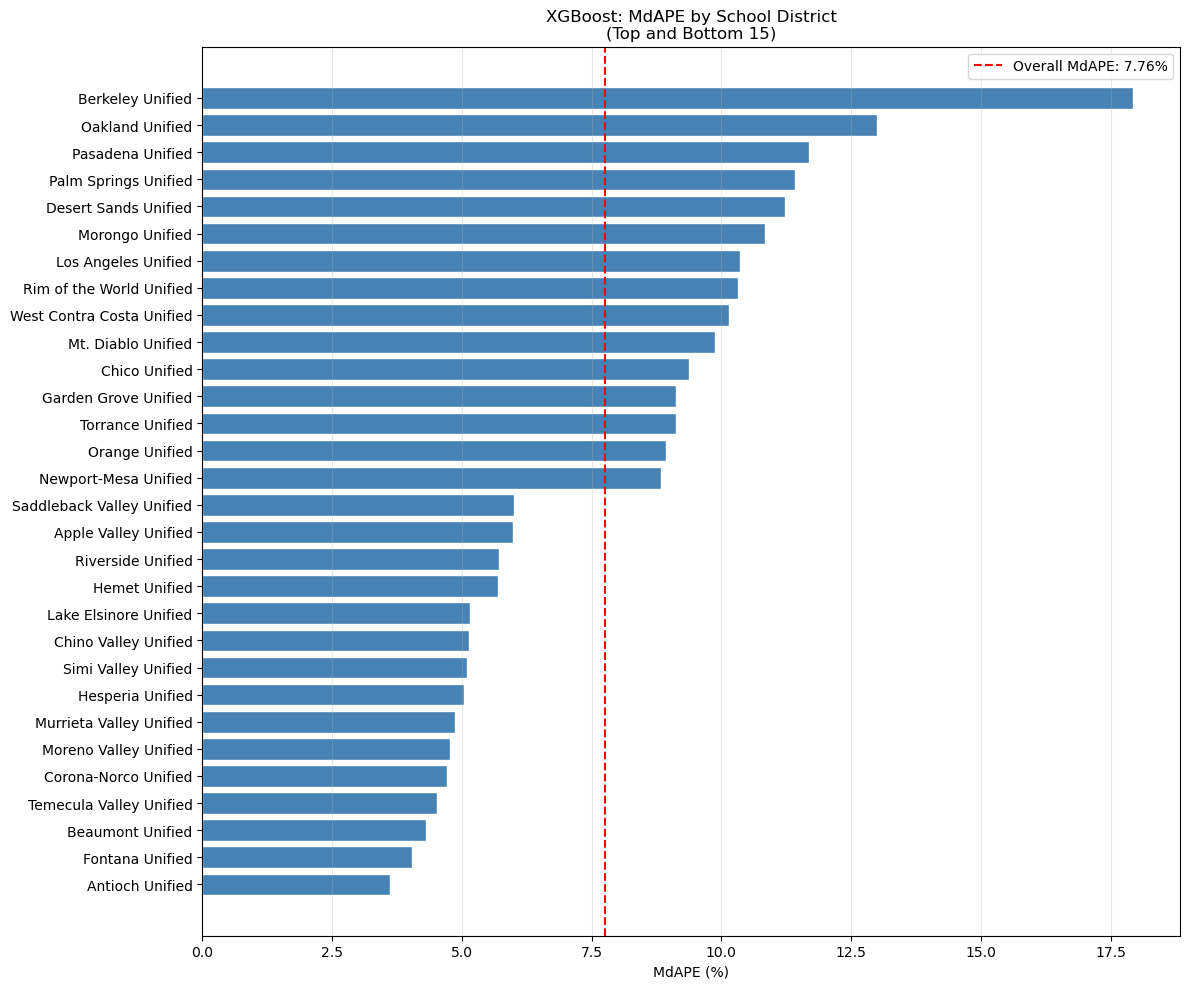

In [51]:
# ============================================
# error by school district
# ============================================

eval_df["District"] = test_df["DistrictName"].reset_index(drop=True)

district_metrics = eval_df.groupby("District").agg(
    Count=("ActualPrice", "count"),
    MdAPE=("APE", "median"),
    MAPE=("APE", "mean"),
    MedianPrice=("ActualPrice", "median")
).round(2)

# only districts with 50+ samples
district_metrics = district_metrics[district_metrics["Count"] >= 50].sort_values("MdAPE")

print(f"Districts with 50+ test samples: {len(district_metrics)}")
print("\nBest performing districts:")
print(district_metrics.head(10))
print("\nWorst performing districts:")
print(district_metrics.tail(10))

# plot top and bottom 15
plot_df = pd.concat([district_metrics.head(15), district_metrics.tail(15)])

fig, ax = plt.subplots(figsize=(12, 10))
ax.barh(plot_df.index, plot_df["MdAPE"], color="steelblue", edgecolor="white")
ax.axvline(x=eval_df["APE"].median(), color="red", linestyle="--",
           label=f"Overall MdAPE: {eval_df['APE'].median():.2f}%")
ax.set_xlabel("MdAPE (%)")
ax.set_title("XGBoost: MdAPE by School District\n(Top and Bottom 15)")
ax.legend()
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(filepath + r"\mdape_by_district.png", dpi=150, bbox_inches='tight')
plt.show()

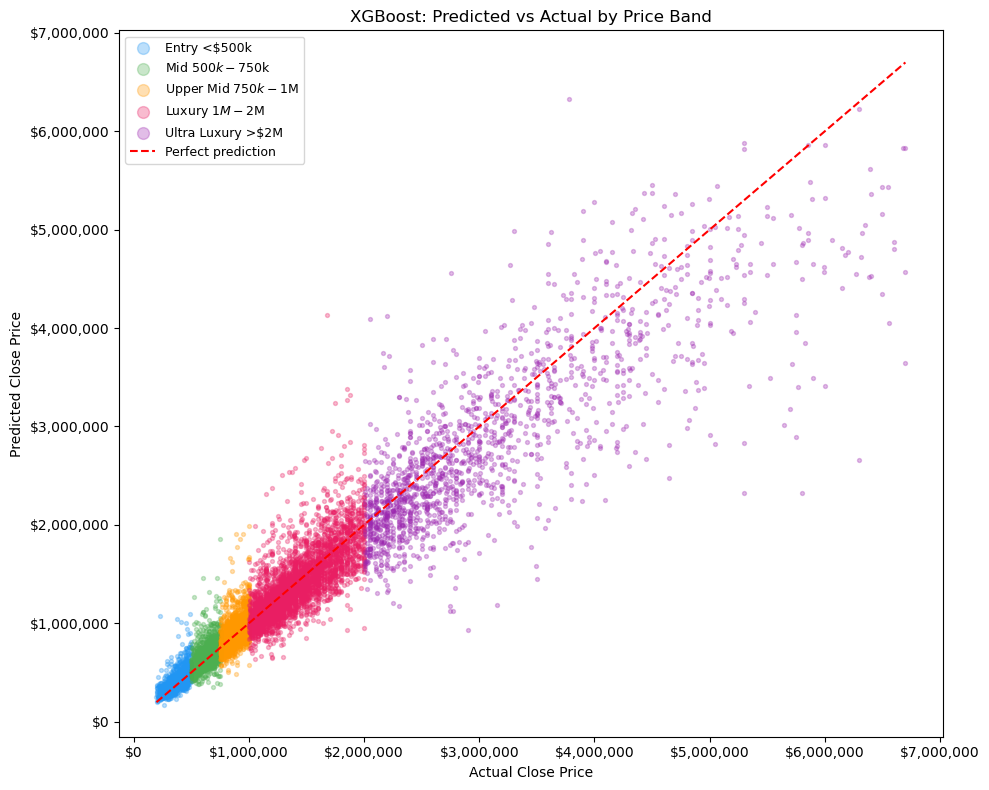

In [53]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = {"Entry\n<$500k": "#2196F3", "Mid\n$500k-$750k": "#4CAF50", 
          "Upper Mid\n$750k-$1M": "#FF9800", "Luxury\n$1M-$2M": "#E91E63",
          "Ultra Luxury\n>$2M": "#9C27B0"}

for band, group in eval_df.groupby("PriceBand", observed=True):
    ax.scatter(group["ActualPrice"], group["PredictedPrice"],
               alpha=0.3, s=8, label=band.replace("\n", " "),
               color=colors[band])

ax.plot([y_test_v.min(), y_test_v.max()],
        [y_test_v.min(), y_test_v.max()],
        color="red", linestyle="--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Close Price")
ax.set_ylabel("Predicted Close Price")
ax.set_title("XGBoost: Predicted vs Actual by Price Band")
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.legend(markerscale=3, fontsize=9)
plt.tight_layout()
plt.savefig(filepath + r"\predicted_vs_actual_by_band.png", dpi=150, bbox_inches='tight')
plt.show()

BedroomBand
1-2 bed    5342
3 bed       200
4 bed        39
5+ bed        8
Name: count, dtype: int64
BedroomBand             1-2 bed      3 bed       4 bed     5+ bed
PriceBand                                                        
Entry\n<$500k          7.312044        NaN  146.606828  20.706832
Mid\n$500k-$750k       5.236081   6.693641   14.564228        NaN
Upper Mid\n$750k-$1M   6.101820   8.935816   11.285063   5.114138
Luxury\n$1M-$2M        7.940838   8.327311   11.808963  20.737044
Ultra Luxury\n>$2M    10.567751  11.826368    9.880524  17.129532


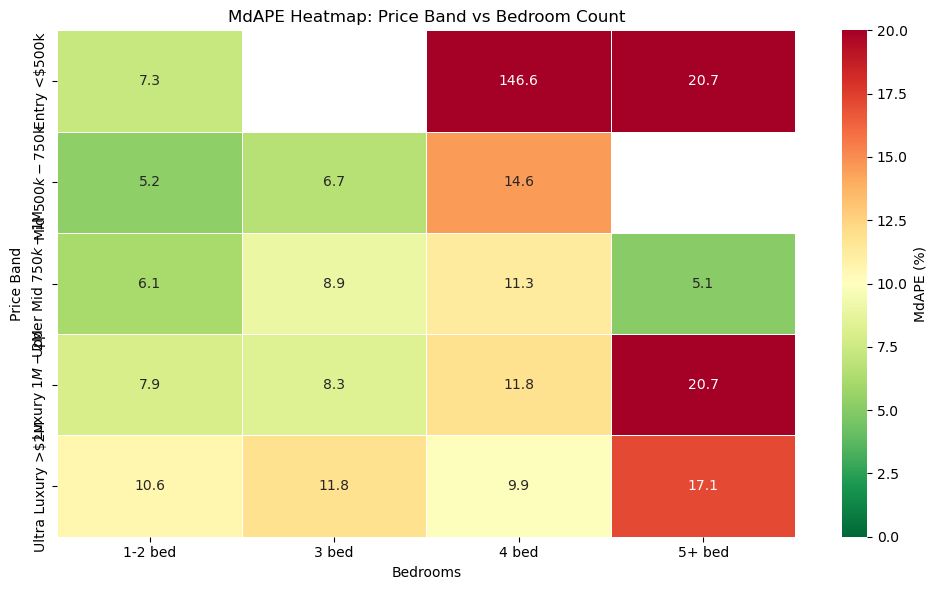

In [72]:
# add bedrooms from test features
eval_df["Bedrooms"] = x_test_v["BedroomsTotal"].reset_index(drop=True)

eval_df["BedroomBand"] = pd.cut(eval_df["Bedrooms"],
                                 bins=[0, 2, 3, 4, 10],
                                 labels=["1-2 bed", "3 bed", "4 bed", "5+ bed"])

print(eval_df["BedroomBand"].value_counts())

# rebuild heatmap
heatmap_data = eval_df.groupby(
    ["PriceBand", "BedroomBand"], observed=True
)["APE"].median().unstack()

print(heatmap_data)

# plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn_r",
            ax=ax, linewidths=0.5, cbar_kws={"label": "MdAPE (%)"},
            vmin=0, vmax=20,
            mask=heatmap_data.isna())
ax.set_xlabel("Bedrooms")
ax.set_ylabel("Price Band")
ax.set_title("MdAPE Heatmap: Price Band vs Bedroom Count")
ax.set_yticklabels([t.get_text().replace("\n", " ") for t in ax.get_yticklabels()])
plt.tight_layout()
plt.savefig(filepath + r"\mdape_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

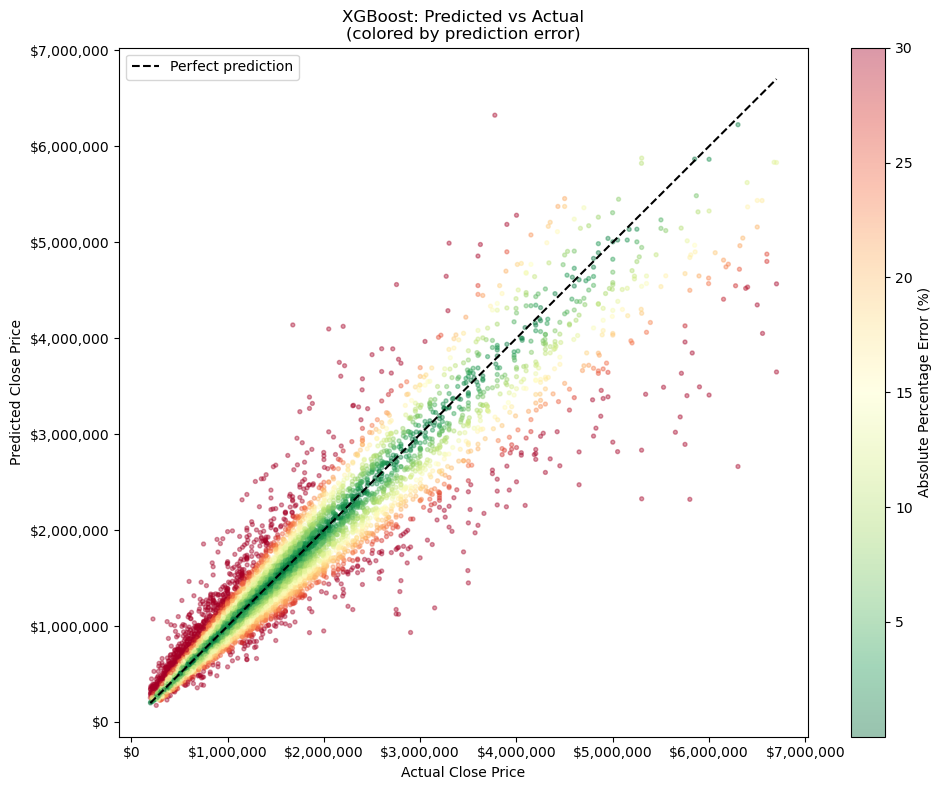

In [80]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    eval_df["ActualPrice"], 
    eval_df["PredictedPrice"],
    c=eval_df["APE"].clip(0, 30),  # cap at 30% for color scale
    cmap="RdYlGn_r",
    alpha=0.4,
    s=8
)

ax.plot([y_test_v.min(), y_test_v.max()],
        [y_test_v.min(), y_test_v.max()],
        color="black", linestyle="--", linewidth=1.5, label="Perfect prediction")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Absolute Percentage Error (%)")

ax.set_xlabel("Actual Close Price")
ax.set_ylabel("Predicted Close Price")
ax.set_title("XGBoost: Predicted vs Actual\n(colored by prediction error)")
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(filepath + r"\predicted_vs_actual_error.png", dpi=150, bbox_inches='tight')
plt.show()

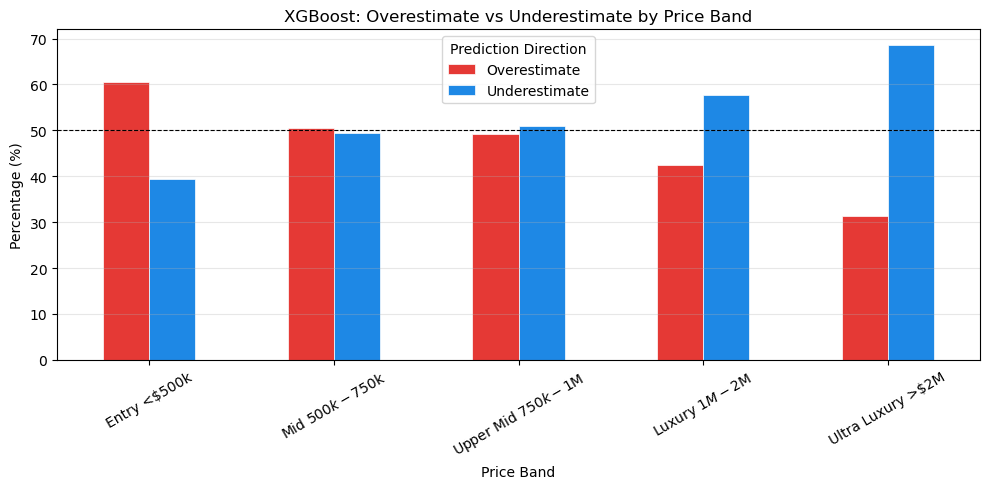

In [59]:
eval_df["Direction"] = np.where(
    eval_df["PredictedPrice"] > eval_df["ActualPrice"], 
    "Overestimate", "Underestimate"
)

direction_by_band = eval_df.groupby(
    ["PriceBand", "Direction"], observed=True
).size().unstack(fill_value=0)

direction_by_band_pct = direction_by_band.div(direction_by_band.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
direction_by_band_pct.plot(kind="bar", ax=ax, 
                            color=["#E53935", "#1E88E5"],
                            edgecolor="white", linewidth=0.5)
ax.axhline(y=50, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Price Band")
ax.set_ylabel("Percentage (%)")
ax.set_title("XGBoost: Overestimate vs Underestimate by Price Band")
ax.set_xticklabels([t.get_text().replace("\n", " ") for t in ax.get_xticklabels()], 
                    rotation=30)
ax.legend(title="Prediction Direction")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(filepath + r"\over_under_estimate.png", dpi=150, bbox_inches='tight')
plt.show()

## Model Evaluation Summary — XGBoost (Tuned)

### Overall Performance
The final XGBoost model achieved an R² of 0.9070 and a MdAPE of 7.66% on the 
June 2026 test set, meaning the model predicts the sale price of a typical 
California single-family home within 7.66% of the actual value. This represents 
a 22+ percentage point improvement over the Linear Regression baseline (MdAPE 30.42%).

### Performance by Price Band
The model performs best on mid-market properties where training data is most abundant:

- Mid (500k-750k): MdAPE 6.29%, MAPE 9.69%
- Upper Mid (750k-1M): MdAPE 6.58%, MAPE 9.28%
- Entry (under 500k): MdAPE 8.00%, MAPE 14.14%
- Luxury (1M-2M): MdAPE 8.62%, MAPE 11.28%
- Ultra Luxury (over 2M): MdAPE 11.25%, MAPE 14.15%

It seems that the Performance degrades at the extremes —>  entry level due to fewer sub-500k 
transactions in training data, ultra luxury due to the uniqueness of high-end properties.
Entry level properties underperform despite their relative simplicity, 
likely due to fewer California sub-$500k transactions in the training data.
Properies over 2m are a bit harder to value, likely due to their sparseness across sales and less generalizable features.

### Overestimate vs Underestimate
The model shows a slight tendency to overestimate on entry level properties 
and underestimate on ultra luxury properties.

### Geographic Performance
Performance varies meaningfully by school district, with districts that have 
more uniform housing stock (suburban unified districts with consistent lot sizes 
and home types) showing lower MdAPE than districts with high price variance 
(coastal luxury markets, mixed urban/rural districts).

### Key Limitations
- Ultra luxury properties (>$2M) show materially higher error (11.25% MdAPE) 
  and should be interpreted with caution
- The model was trained on 2023-2026 data — performance may degrade if market 
  conditions shift significantly
- Properties in school districts with few training examples (sparse markets) 
  may have less reliable predictions
